steady values after step:
  c_out        = 0.022748
  c_F          = 0.12867
  DF           = 1.9994
  SL           = 0.14554
  E            = 3.1921
  DR_wash      = 0.85
  DR_apparent  = 0.89071
  L10          = 5599.6
  c_T          = 0.14081


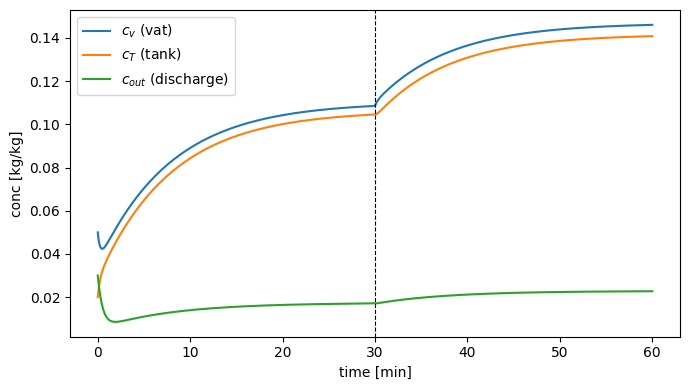

In [1]:
import numpy as np
from scipy.integrate import solve_ivp

class Washer:
    def __init__(self, PR=600.0, N1=0.12, N2=0.012, N3=0.10, N4=0.10, N5=0.13, WL=5215.0, c_in=0.15, c_WL=0.001, 
                 DR=0.85, tau_d=0.5, m_v_sp=20000.0, m_T_sp=30000.0, Kp_v=5.0, Kp_T=5.0):
        self.PR = PR
        self.N = (N1, N2, N3, N4, N5)
        self.WL = WL
        self.c_in = c_in
        self.c_WL = c_WL
        self.DR = DR
        self.tau_d = tau_d
        self.m_v_sp = m_v_sp
        self.m_T_sp = m_T_sp
        self.Kp_v, self.Kp_T = Kp_v, Kp_T

        # liquor to pulp ratio defined by consistency
        r = [(1.0 - n) / n for n in self.N]
        self.L1, self.L2, self.L3, self.L4, self.L5 = [PR * ri for ri in r]

        # nominal control flows that close the steady-state balance
        self.L6_nom = self.L2 - self.L1
        self.L9_nom = (self.L2 - self.L3) + (self.L3 + WL - self.L4) + (self.L4 - self.L5)

    def dr(self, c3, c_v, c_T):
        # yet to insert dynamic DR function here
        return self.DR(c3, c_v, c_T) if callable(self.DR) else self.DR

    def algebraic(self, y, c_in):
        m_v, m_sv, m_T, m_sT, c4 = y
        c_v = m_sv / m_v
        c_T = m_sT / m_T
        L1, L2, L3, L4, L5, WL, c_WL = self.L1, self.L2, self.L3, self.L4, self.L5, self.WL, self.c_WL

        # Flow control of recycle to vat, yet to be replaced by PI control
        L6 = max(0.0, self.L6_nom - self.Kp_v * (m_v - self.m_v_sp))

        # Washing (wash zone)
        c3 = c_v
        F = L3 + WL - L4
        DR = self.dr(c3, c_v, c_T)
        c4_ss = (1.0 - DR) * c3 + DR * c_WL
        c_F = (L3 * c3 + WL * c_WL - L4 * c4) / F

        # Formation / dewatering drainage to the tank
        L7 = L2 - L3
        L8 = L4 - L5

        # Flow control of F9 to maintain seal tank level
        L9 = max(0.0, self.L9_nom + self.Kp_T * (m_T - self.m_T_sp))

        # Distributor
        L10 = L9 - L6

        return dict(c_v=c_v, c_T=c_T, c3=c3, c4_ss=c4_ss, c_F=c_F, L6=L6, L7=L7, L8=L8, L9=L9, L10=L10, F=F, DR=DR)

    def rhs(self, t, y, c_in_func):
        m_v, m_sv, m_T, m_sT, c4 = y
        c_in = c_in_func(t)
        a = self.algebraic(y, c_in)
        L1, L2 = self.L1, self.L2

        # dilution vat (CSTR): liquor and solute holdup
        dm_v = L1 + a['L6'] - L2
        dm_sv = L1 * c_in + a['L6'] * a['c_T'] - L2 * a['c_v']

        # filtrate/seal tank (CSTR): liquor and solute holdup
        dm_T = (a['L7'] + a['F'] + a['L8']) - a['L9']
        dm_sT = a['L7'] * a['c3'] + a['F'] * a['c_F'] + a['L8'] * c4 - a['L9'] * a['c_T']

        # wash zone (drum transport delay)
        dc4 = (a['c4_ss'] - c4) / self.tau_d

        return [dm_v, dm_sv, dm_T, dm_sT, dc4]

    def simulate(self, t_span, y0, c_in_func, n=600):
        t_eval = np.linspace(*t_span, n)
        return solve_ivp(self.rhs, t_span, y0, args=(c_in_func,),
                         method='LSODA', t_eval=t_eval, rtol=1e-7, atol=1e-9)

    def diagnostics(self, y, c_in):
        a = self.algebraic(y, c_in)
        c_out = y[4]
        DF = (self.WL - self.L5) / self.PR
        SL = (c_out - self.c_WL) * self.L5 / self.PR
        A = self.WL / self.L5
        arg = (A - a['DR']) / (1.0 - a['DR'])
        E = np.log(arg) / np.log(A) - 1.0 if (arg > 0 and A > 0 and A != 1) else float('nan')
        DR_app = (c_in - c_out) / (c_in - self.c_WL)
        return dict(c_out=c_out, c_F=a['c_F'], DF=DF, SL=SL, E=E,
                    DR_wash=a['DR'], DR_apparent=DR_app, L10=a['L10'], c_T=a['c_T'])


if __name__ == "__main__":
    w = Washer()
    y0 = [w.m_v_sp, w.m_v_sp * 0.05, w.m_T_sp, w.m_T_sp * 0.02, 0.03]

    # step the feed concentration 0.15 -> 0.20 at t = 30 min
    c_in_func = lambda t: 0.15 if t < 30.0 else 0.20

    sol = w.simulate((0.0, 60.0), y0, c_in_func)
    y_end = sol.y[:, -1]
    d = w.diagnostics(y_end, c_in_func(60.0))

    print("steady values after step:")
    for k, v in d.items():
        print(f"  {k:12s} = {v:.5g}")


    import matplotlib.pyplot as plt

    c_v = sol.y[1] / sol.y[0]
    c_T = sol.y[3] / sol.y[2]
    c_out = sol.y[4]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(sol.t, c_v, label=r"$c_v$ (vat)")
    ax.plot(sol.t, c_T, label=r"$c_T$ (tank)")
    ax.plot(sol.t, c_out, label=r"$c_{out}$ (discharge)")
    ax.axvline(30, ls="--", c="k", lw=0.8)
    ax.set_xlabel("time [min]"); ax.set_ylabel("conc [kg/kg]")
    ax.legend(); fig.tight_layout()
    plt.show()
